# StreamTrack — basic use

Shows how to build a smooth phase-space track from a `fardal15spraydf`
(or `chen24spraydf`) with `basestreamspraydf.streamTrack()`, and
exercises the public API: accessors, covariance in multiple bases,
spread bands, smoothing control, iteration, particle reuse, and the
custom-sky frame.

The underlying class is `galpy.df.streamTrack.StreamTrack` (one arm);
`streamTrack(tail='both')` returns a `StreamTrackPair` containing both
arms.

**Conventions.** The track's time coordinate `tp` is the progenitor's
orbital time: `tp=0` is the progenitor today, `tp>0` is the
progenitor's future (where leading-arm material sits), `tp<0` is its
past (trailing arm). Use `track.tp_grid()` to get the valid range
for each arm.

In [1]:
import numpy
from matplotlib import pyplot
from astropy import units as u

from galpy.df import fardal15spraydf, chen24spraydf
from galpy.orbit import Orbit
from galpy.potential import LogarithmicHaloPotential
from galpy.util import coords

%matplotlib inline

# Canonical Bovy-2014 setup: flattened logarithmic halo, cluster on a
# particular 6D orbit that produces a long, bent stream.
lp = LogarithmicHaloPotential(normalize=1.0, q=0.9)
prog = Orbit(
    [1.56148083, 0.35081535, -1.15481504, 0.88719443, -0.47713334, 0.12019596],
    ro=8.0, vo=220.0,
)

spdf = fardal15spraydf(
    progenitor_mass=2e4 * u.Msun,
    progenitor=prog,
    pot=lp,
    tdisrupt=4.5 * u.Gyr,
    tail="both",
)

## 1. Custom sky frame from the progenitor's orbit

`Orbit.align_to_orbit(center_phi1=180)` returns a 3×3 rotation matrix
that, when used as a `custom_transform=` argument to `streamTrack`
(or passed to `coords.radec_to_custom`), maps equatorial (ra, dec) to
a frame where the orbit's orbital plane lies at phi₂ ≈ 0 and the
progenitor sits at phi₁ = 180°. Streams then run horizontally and
wrap naturally across 0/360°.

Building the track with `custom_transform` enabled also lights up the
`.phi1`, `.phi2`, `.pmphi1`, `.pmphi2` accessors and the `customsky`
covariance basis.

In [2]:
T = prog.align_to_orbit()   # default center_phi1=180°

numpy.random.seed(0)
track = spdf.streamTrack(n=2000, tail="both", custom_transform=T)

# One particle sample per arm lives on each track — no need to resample.
xv_l, dt_l = track.leading.particles
xv_t, dt_t = track.trailing.particles
print(f"leading arm: {xv_l.shape[1]} particles, "
      f"trailing arm: {xv_t.shape[1]} particles")

  0%|          | 0/500 [00:00<?, ?it/s]

 14%|█▍        | 72/500 [00:00<00:00, 708.87it/s]

 19%|█▊        | 93/500 [00:00<00:00, 813.44it/s]

 28%|██▊       | 139/500 [00:00<00:00, 813.44it/s]

 29%|██▉       | 146/500 [00:00<00:00, 813.44it/s]

...

 95%|█████████▍| 1897/2000 [00:00<00:00, 1214.02it/s]

 96%|█████████▌| 1911/2000 [00:00<00:00, 1214.02it/s]

 99%|█████████▉| 1975/2000 [00:00<00:00, 1214.02it/s]

 99%|█████████▉| 1988/2000 [00:00<00:00, 1214.02it/s]

leading arm: 2000 particles, trailing arm: 2000 particles


## 2. Galactocentric (x, y) and (R, z) with ±σ bands

`track.plot(d1, d2, spread=k)` overlays the mean track and, for any
`d2` with a basis in the internal dispatch (see section 4), a ±k·σ
band drawn from the propagated covariance. Here we compare to the
particles that were used to build the fit — these are retrieved from
`track.leading.particles` rather than drawing a fresh sample.

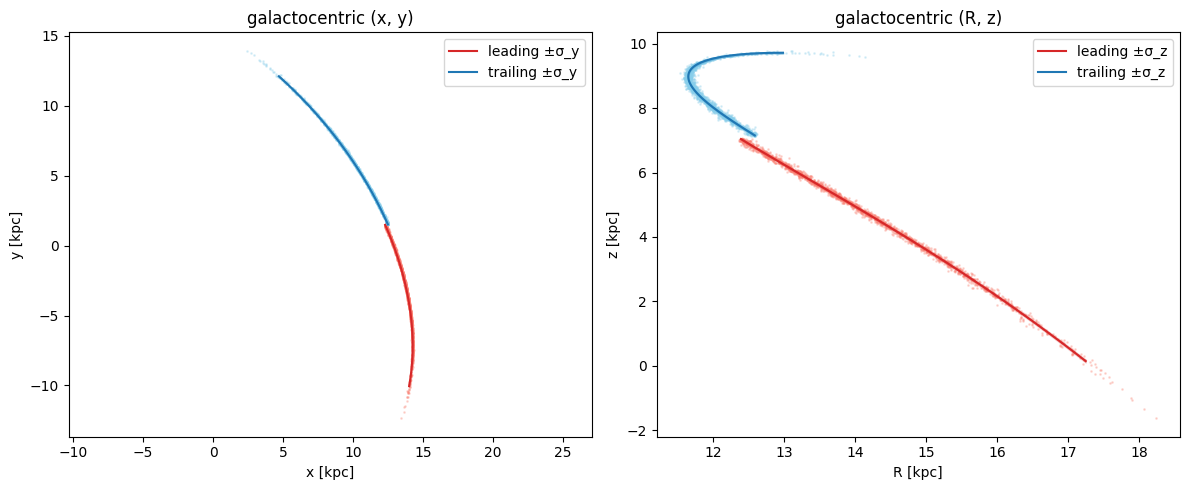

In [3]:
# Convert each arm's raw (xv, dt) to Cartesian for the scatter.
def particles_xyz(xv):
    R, phi, z = xv[0], xv[5], xv[3]
    return R * numpy.cos(phi) * 8.0, R * numpy.sin(phi) * 8.0, z * 8.0

x_l, y_l, z_l = particles_xyz(xv_l)
x_t, y_t, z_t = particles_xyz(xv_t)

fig, axes = pyplot.subplots(1, 2, figsize=(12, 5))

ax = axes[0]; pyplot.sca(ax)
ax.scatter(x_l, y_l, s=1, alpha=0.25, color="salmon")
ax.scatter(x_t, y_t, s=1, alpha=0.25, color="skyblue")
track.leading.plot(d1="x", d2="y", spread=1, color="C3", label="leading ±σ_y")
track.trailing.plot(d1="x", d2="y", spread=1, color="C0", label="trailing ±σ_y")
ax.set_xlabel("x [kpc]"); ax.set_ylabel("y [kpc]")
ax.set_aspect("equal", adjustable="datalim")
ax.set_title("galactocentric (x, y)"); ax.legend()

ax = axes[1]; pyplot.sca(ax)
R_l = numpy.sqrt(x_l**2 + y_l**2); R_t = numpy.sqrt(x_t**2 + y_t**2)
ax.scatter(R_l, z_l, s=1, alpha=0.25, color="salmon")
ax.scatter(R_t, z_t, s=1, alpha=0.25, color="skyblue")
track.leading.plot(d1="R", d2="z", spread=1, color="C3", label="leading ±σ_z")
track.trailing.plot(d1="R", d2="z", spread=1, color="C0", label="trailing ±σ_z")
ax.set_xlabel("R [kpc]"); ax.set_ylabel("z [kpc]")
ax.set_title("galactocentric (R, z)"); ax.legend()

fig.tight_layout()

## 3. Heliocentric sky with ±σ bands

The `spread=k` band now works on any supported axis, including the
heliocentric equatorial (ra, dec, pmra, pmdec, vlos) and Galactic
(ll, bb, pmll, pmbb) coordinates. Spread is drawn perpendicular to
`d1` along `d2` using the cov expressed in the appropriate basis.

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 1/2000 [00:00<10:40,  3.12it/s]

  0%|          | 2/2000 [00:00<06:44,  4.94it/s]

 31%|███       | 621/2000 [00:00<00:01, 1163.91it/s]

 33%|███▎      | 653/2000 [00:00<00:00, 5705.43it/s]

...

 99%|█████████▉| 1984/2000 [00:00<00:00, 2002.43it/s]

100%|█████████▉| 1994/2000 [00:00<00:00, 2002.43it/s]

100%|█████████▉| 1998/2000 [00:00<00:00, 2002.43it/s]

100%|██████████| 2000/2000 [00:00<00:00, 2002.43it/s]

100%|██████████| 2000/2000 [00:00<00:00, 2002.43it/s]

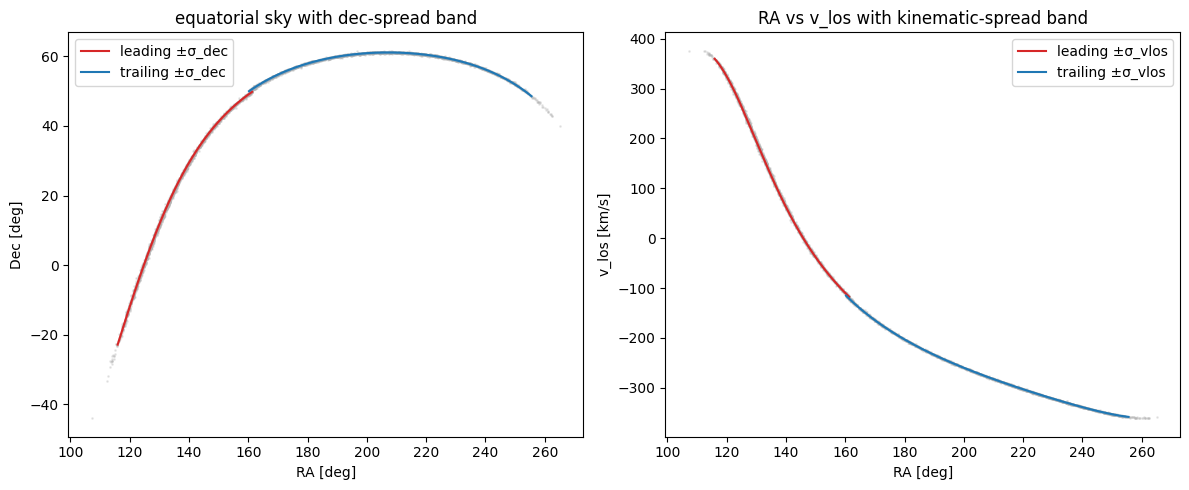

In [4]:
# Build a samples Orbit for scatter (one extra draw so the underlying
# 3D samples aren't identical to what lives on the track — the
# point here is to show the band extent, not verify sample/track
# agreement).
numpy.random.seed(5)
samples = spdf.sample(n=4000)

fig, axes = pyplot.subplots(1, 2, figsize=(12, 5))
ax = axes[0]; pyplot.sca(ax)
ax.scatter(samples.ra(), samples.dec(), s=1, alpha=0.25, color="0.7")
track.leading.plot(d1="ra", d2="dec", spread=1, color="C3",
                   label="leading ±σ_dec")
track.trailing.plot(d1="ra", d2="dec", spread=1, color="C0",
                    label="trailing ±σ_dec")
ax.set_xlabel("RA [deg]"); ax.set_ylabel("Dec [deg]"); ax.legend()
ax.set_title("equatorial sky with dec-spread band")

ax = axes[1]; pyplot.sca(ax)
ax.scatter(samples.ra(), samples.vlos(), s=1, alpha=0.25, color="0.7")
track.leading.plot(d1="ra", d2="vlos", spread=1, color="C3",
                   label="leading ±σ_vlos")
track.trailing.plot(d1="ra", d2="vlos", spread=1, color="C0",
                    label="trailing ±σ_vlos")
ax.set_xlabel("RA [deg]"); ax.set_ylabel("v_los [km/s]"); ax.legend()
ax.set_title("RA vs v_los with kinematic-spread band")

fig.tight_layout()

## 4. Aligned (φ₁, φ₂) view via `custom_transform`

Because we passed `custom_transform=T`, the track has `.phi1`, `.phi2`,
`.pmphi1`, `.pmphi2` accessors and the `customsky` covariance basis —
so the progenitor-L-aligned view is a one-liner now (no manual
rotation-matrix bookkeeping in the notebook).

In this frame the stream runs horizontally with phi₂ ≈ 0; the ±σ band
around the mean line is the true cross-stream width.

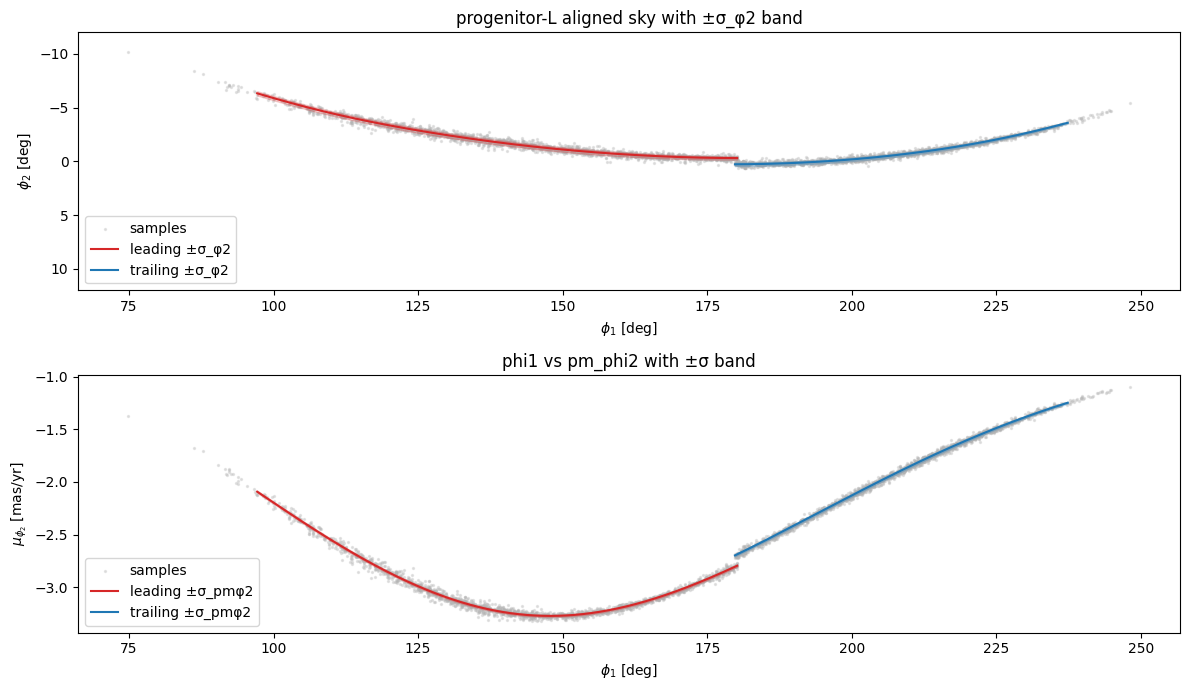

In [5]:
# Scatter the same samples (transform their sky coords to customsky)
p1_s, p2_s = coords.radec_to_custom(
    numpy.atleast_1d(samples.ra()),
    numpy.atleast_1d(samples.dec()),
    T=T, degree=True,
).T

fig, axes = pyplot.subplots(2, 1, figsize=(12, 7))
ax = axes[0]; pyplot.sca(ax)
ax.scatter(p1_s, p2_s, s=2, alpha=0.3, color="0.7", label="samples")
track.leading.plot(d1="phi1", d2="phi2", spread=1, color="C3",
                   label="leading ±σ_φ2")
track.trailing.plot(d1="phi1", d2="phi2", spread=1, color="C0",
                    label="trailing ±σ_φ2")
ax.set_xlabel(r"$\phi_1$ [deg]"); ax.set_ylabel(r"$\phi_2$ [deg]")
ax.set_ylim(12, -12); ax.legend()
ax.set_title("progenitor-L aligned sky with ±σ_φ2 band")

# Proper-motion band in the same frame
pm_p1_s, pm_p2_s = coords.pmrapmdec_to_custom(
    numpy.atleast_1d(samples.pmra()),
    numpy.atleast_1d(samples.pmdec()),
    numpy.atleast_1d(samples.ra()),
    numpy.atleast_1d(samples.dec()),
    T=T, degree=True,
).T

ax = axes[1]; pyplot.sca(ax)
ax.scatter(p1_s, pm_p2_s, s=2, alpha=0.3, color="0.7", label="samples")
track.leading.plot(d1="phi1", d2="pmphi2", spread=1, color="C3",
                   label="leading ±σ_pmφ2")
track.trailing.plot(d1="phi1", d2="pmphi2", spread=1, color="C0",
                    label="trailing ±σ_pmφ2")
ax.set_xlabel(r"$\phi_1$ [deg]"); ax.set_ylabel(r"$\mu_{\phi_2}$ [mas/yr]")
ax.legend(); ax.set_title("phi1 vs pm_phi2 with ±σ band")

fig.tight_layout()

## 5. Covariance accessors

`track.cov(tp, basis=...)` returns the 6×6 covariance in the requested
basis. The propagated matrices all pass through analytical Jacobians
(no finite differences).

Supported bases: `galcenrect` (default), `galcencyl`, `sky`, `galsky`,
`customsky`.

In [6]:
tp0 = 0.5 * track.leading.tp_grid().max()   # midway along leading arm
names = {
    "galcenrect": ("x", "y", "z", "vx", "vy", "vz"),
    "galcencyl":  ("R", "vR", "vT", "z", "vz", "phi"),
    "sky":        ("ra", "dec", "dist", "pmra", "pmdec", "vlos"),
    "galsky":     ("ll", "bb", "dist", "pmll", "pmbb", "vlos"),
    "customsky":  ("phi1", "phi2", "dist", "pmphi1", "pmphi2", "vlos"),
}
print(f"tp = {tp0:.3f}   (cov σ = sqrt(diag) in each basis)")
for basis, labels in names.items():
    C = track.leading.cov(tp0, basis=basis)
    sigmas = numpy.sqrt(numpy.diag(C))
    print(f"  {basis:<12s} " + "  ".join(
        f"{lbl}={sig:.3g}" for lbl, sig in zip(labels, sigmas)
    ))

tp = 0.692   (cov σ = sqrt(diag) in each basis)
  galcenrect   x=0.0264  y=0.0244  z=0.0367  vx=0.48  vy=0.212  vz=0.301
  galcencyl    R=0.0268  vR=0.575  vT=0.382  z=0.0367  vz=0.301  phi=0.00162
  sky          ra=0.223  dec=0.106  dist=0.0363  pmra=0.0125  pmdec=0.0319  vlos=0.601
  galsky       ll=0.182  bb=0.183  dist=0.0363  pmll=0.0288  pmbb=0.0225  vlos=0.601
  customsky    phi1=0.107  phi2=0.22  dist=0.0363  pmphi1=0.0313  pmphi2=0.012  vlos=0.601


## 6. Accessors and one covariance in detail

In [7]:
print(f"tp = {tp0:.3f}")
print(f"  galactocentric (x, y, z)    = "
      f"({track.leading.x(tp0):.2f}, {track.leading.y(tp0):.2f}, "
      f"{track.leading.z(tp0):.2f}) kpc")
print(f"  galactocentric (vx, vy, vz) = "
      f"({track.leading.vx(tp0):.1f}, {track.leading.vy(tp0):.1f}, "
      f"{track.leading.vz(tp0):.1f}) km/s")
print(f"  cylindrical (R, vR, vT, z, vz, phi) = {track.leading(tp0)}")
print(f"  sky: RA={track.leading.ra(tp0):.2f}°  "
      f"Dec={track.leading.dec(tp0):.2f}°  "
      f"d={track.leading.dist(tp0):.2f} kpc  "
      f"vlos={track.leading.vlos(tp0):.1f} km/s")
print(f"  customsky: φ1={track.leading.phi1(tp0):.2f}°  "
      f"φ2={track.leading.phi2(tp0):.2f}°  "
      f"pmφ1·cosφ2={track.leading.pmphi1(tp0):.3f} mas/yr  "
      f"pmφ2={track.leading.pmphi2(tp0):.3f} mas/yr")

C = track.leading.cov(tp0, basis="customsky")
print(f"\ncustomsky covariance (6×6) at tp={tp0:.3f}")
print(f"  min eigenvalue = {numpy.linalg.eigvalsh(C).min():.2e}   (≥0 → PSD)")

tp = 0.692
  galactocentric (x, y, z)    = (14.08, -4.56, 3.88) kpc
  galactocentric (vx, vy, vz) = (34.7, -234.8, -142.5) km/s
  cylindrical (R, vR, vT, z, vz, phi) = [ 1.84987679  0.47876826 -0.96669605  0.48558617 -0.64751312 -0.31317825]
  sky: RA=128.61°  Dec=8.74°  d=8.52 kpc  vlos=214.6 km/s
  customsky: φ1=130.95°  φ2=-2.35°  pmφ1·cosφ2=-10.519 mas/yr  pmφ2=-3.116 mas/yr

customsky covariance (6×6) at tp=0.692
  min eigenvalue = 7.94e-06   (≥0 → PSD)


## 7. Effect of the `smoothing` parameter

`smoothing=None` (default) uses scipy's GCV auto-tuning. A float sets
an explicit `s` for all mean splines — smaller ⇒ follows noise, larger
⇒ over-smooths. Easiest to see in the aligned frame.

In [8]:
numpy.random.seed(1)
tr_auto  = spdf.streamTrack(n=2000, tail="both", custom_transform=T)
numpy.random.seed(1)
tr_tight = spdf.streamTrack(n=2000, tail="both", custom_transform=T, smoothing=1.0)
numpy.random.seed(1)
tr_loose = spdf.streamTrack(n=2000, tail="both", custom_transform=T, smoothing=500.0)

fig, ax = pyplot.subplots(figsize=(11, 4))
ax.scatter(p1_s, p2_s, s=2, alpha=0.2, color="0.75", label="samples")
for tr_, col, lab in [(tr_tight, "C0", "tight (s=1)"),
                      (tr_auto,  "C1", "auto (GCV)"),
                      (tr_loose, "C3", "loose (s=500)")]:
    for arm in (tr_.leading, tr_.trailing):
        arm.plot(d1="phi1", d2="phi2", color=col,
                 label=lab if arm is tr_.leading else None)
ax.set_ylim(12, -12); ax.set_xlabel(r"$\phi_1$"); ax.set_ylabel(r"$\phi_2$")
ax.legend(); ax.set_title("smoothing controls the mean track's flexibility")
fig.tight_layout()

  0%|          | 0/500 [00:00<?, ?it/s]

 12%|█▏        | 61/500 [00:00<00:00, 608.92it/s]

 24%|██▍       | 120/500 [00:00<00:00, 1090.58it/s]

 26%|██▌       | 130/500 [00:00<00:00, 1090.58it/s]

 26%|██▋       | 132/500 [00:00<00:00, 1090.58it/s]

...

      File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 1347, in refresh
    self.display()
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 1495, in display
    self.sp(self.__str__() if msg is None else msg)
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 459, in print_status
    fp_write('\r' + s + (' ' * max(last_len[0] - len_s, 0)))
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 453, in fp_write
    fp_flush()
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/utils.py", line 196, in inner
    return func(*args, **kwargs)
  File "/home/bovy/miniforge3/envs/py313/lib/python3.13/site-packages/ipykernel/iostream.py", line 670, in flush
    self.pub_thread.schedule(self._flush)
  File "/home/bovy/miniforge3/envs/py313/lib/python3.13/site-packages/ipykernel/iostream.py", line 339, in schedule
    self._event_pipe.send(b"")
  File "/home/bovy/miniforge3/envs/py313/lib/p

      File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 1347, in refresh


      File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 1495, in display
    self.sp(self.__str__() if msg is None else msg)
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 459, in print_status
    fp_write('\r' + s + (' ' * max(last_len[0] - len_s, 0)))
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 453, in fp_write
    fp_flush()
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/utils.py", line 196, in inner
    return func(*args, **kwargs)
  File "/home/bovy/miniforge3/envs/py313/lib/python3.13/site-packages/ipykernel/iostream.py", line 670, in flush
    self.pub_thread.schedule(self._flush)
  File "/home/bovy/miniforge3/envs/py313/lib/python3.13/site-packages/ipykernel/iostream.py", line 339, in schedule
    self._event_pipe.send(b"")
  File "/home/bovy/miniforge3/envs/py313/lib/python3.13/site-packages/ipykernel/iostream.py", line 218, in _event_pipe
    event_pipe = ctx.socket(zmq.PUSH)
 

 76%|███████▌  | 1521/2000 [00:22<00:10, 46.98it/s]Exception ignored on calling ctypes callback function <bound method tqdm.update of <tqdm.std.tqdm object at 0x7813d0747750>>:
Traceback (most recent call last):
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 1242, in update
    self.refresh(lock_args=self.lock_args)
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 1347, in refresh
    self.display()
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 1495, in display
    self.sp(self.__str__() if msg is None else msg)
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 459, in print_status
    fp_write('\r' + s + (' ' * max(last_len[0] - len_s, 0)))
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 452, in fp_write
    fp.write(str(s))
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/utils.py", line 196, in inner
    return func(*args, **kwargs)

 76%|███████▌  | 1524/2000 [00:22<00:10, 46.92it/s]Exception ignored on calling ctypes callback function <bound method tqdm.update of <tqdm.std.tqdm object at 0x7813d0747750>>:
Traceback (most recent call last):
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 1242, in update
    self.refresh(lock_args=self.lock_args)
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 1347, in refresh
    self.display()
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 1495, in display
    self.sp(self.__str__() if msg is None else msg)
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 459, in print_status
    fp_write('\r' + s + (' ' * max(last_len[0] - len_s, 0)))
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/std.py", line 452, in fp_write
    fp.write(str(s))
  File "/tmp/exp-env-target/lib/python3.13/site-packages/tqdm/utils.py", line 196, in inner
    return func(*args, **kwargs)

## 8. Iteration (niter)

`niter > 0` reassigns particles to the closest point on the current
fitted track (not the progenitor orbit) and refits. Typically 1–2
iterations are enough.

In [ ]:
numpy.random.seed(2)
tr_i0 = spdf.streamTrack(n=2000, tail="both", custom_transform=T, niter=0)
numpy.random.seed(2)
tr_i1 = spdf.streamTrack(n=2000, tail="both", custom_transform=T, niter=1)
numpy.random.seed(2)
tr_i3 = spdf.streamTrack(n=2000, tail="both", custom_transform=T, niter=3)

for arm_name in ("leading", "trailing"):
    tps = getattr(tr_i0, arm_name).tp_grid()
    def _max_d(a, b):
        return float(numpy.max(numpy.hypot(
            getattr(a, arm_name).x(tps) - getattr(b, arm_name).x(tps),
            getattr(a, arm_name).y(tps) - getattr(b, arm_name).y(tps),
        )))
    print(f"{arm_name}: max |track(niter=0) - track(niter=1)| = "
          f"{_max_d(tr_i0, tr_i1):.3f} kpc")
    print(f"{arm_name}: max |track(niter=1) - track(niter=3)| = "
          f"{_max_d(tr_i1, tr_i3):.3f} kpc  (convergence)")

fig, ax = pyplot.subplots(figsize=(11, 4))
ax.scatter(p1_s, p2_s, s=2, alpha=0.2, color="0.75", label="samples")
for tr_, col, lab in [(tr_i0, "C0", "niter=0"),
                      (tr_i1, "C1", "niter=1"),
                      (tr_i3, "C3", "niter=3")]:
    for arm in (tr_.leading, tr_.trailing):
        arm.plot(d1="phi1", d2="phi2", color=col,
                 label=lab if arm is tr_.leading else None)
ax.set_ylim(12, -12); ax.set_xlabel(r"$\phi_1$"); ax.set_ylabel(r"$\phi_2$")
ax.legend(); ax.set_title("iterated track converges within 1–2 iterations")
fig.tight_layout()

## 9. Reusing the smoothing with `smoothing_s`

After a fit, `track.smoothing_s` contains the effective per-spline `s`
values (6 mean + 21 covariance = 27 when `order=2`). Passing it back
as `smoothing=` reproduces the same fit without re-running GCV.

In [ ]:
saved_s = track.leading.smoothing_s
print(f"smoothing_s length: {len(saved_s)}")
print("first 6 (mean splines):", [float(f'{s:.3g}') for s in saved_s[:6]])

numpy.random.seed(0)
tr_replay = spdf.streamTrack(n=2000, tail="leading",
                             custom_transform=T, smoothing=saved_s)
tps = tr_replay.tp_grid()
max_diff = float(numpy.max(numpy.hypot(
    tr_replay.x(tps) - track.leading.x(tps),
    tr_replay.y(tps) - track.leading.y(tps),
)))
print(f"max |replay - original| in (x, y) = {max_diff:.3e} kpc")

## 10. `chen24spraydf` vs `fardal15spraydf`

In [ ]:
spdf_c = chen24spraydf(
    progenitor_mass=2e4 * u.Msun,
    progenitor=prog,
    pot=lp,
    tdisrupt=4.5 * u.Gyr,
    tail="both",
)
numpy.random.seed(7)
tr_f = spdf.streamTrack(n=2000, tail="both", custom_transform=T)
numpy.random.seed(7)
tr_c = spdf_c.streamTrack(n=2000, tail="both", custom_transform=T)

fig, ax = pyplot.subplots(figsize=(11, 4))
for tr_, col, lab in [(tr_f, "C0", "fardal15"), (tr_c, "C3", "chen24")]:
    for arm in (tr_.leading, tr_.trailing):
        arm.plot(d1="phi1", d2="phi2", color=col,
                 label=lab if arm is tr_.leading else None)
ax.set_xlabel(r"$\phi_1$ [deg]"); ax.set_ylabel(r"$\phi_2$ [deg]")
ax.set_ylim(12, -12); ax.legend()
ax.set_title("fardal15 vs chen24 — same API, small orbit-scale differences")
fig.tight_layout()

## 11. Cross-check against `streamdf`

`streamdf` builds stream tracks from the action-angle DF given the
progenitor's internal radial velocity dispersion `sigv` and an
`actionAngle` instance — a very different pipeline from `fardal15
spraydf`, which samples Lagrange-point offsets in phase space. The
two representations should produce visually-indistinguishable mean
tracks in a shared sky frame if set up consistently. This is both a
sanity check on the new `StreamTrack` machinery and a demonstration
of the shared `custom_transform=` kwarg.

`streamdf` handles one arm per instance (`leading=True`/`False`).

In [ ]:
from galpy.actionAngle import actionAngleIsochroneApprox
from galpy.df import streamdf

# For a 2e4 Msun cluster with r_h ~ 25 pc, sigv ~ sqrt(GM/5r_h) ~ 1 km/s.
# Match sigv by roughly matching the cross-stream width at mid-arm.
sigv_kms = 0.5

# streamdf needs an action-angle evaluator. actionAngleIsochroneApprox is
# the standard choice for general axisymmetric potentials.
aAI = actionAngleIsochroneApprox(pot=lp, b=0.8)

# Pass the same solarmotion as the progenitor to suppress the vsun
# warning and keep observables consistent.
vsun_match = [-11.1, 220. + 12.24, 7.25]

sdf_l = streamdf(
    sigv_kms * u.km / u.s,
    progenitor=prog, pot=lp, aA=aAI,
    leading=True, tdisrupt=4.5 * u.Gyr,
    ro=8., vo=220., vsun=vsun_match,
    custom_transform=T,
)
sdf_t = streamdf(
    sigv_kms * u.km / u.s,
    progenitor=prog, pot=lp, aA=aAI,
    leading=False, tdisrupt=4.5 * u.Gyr,
    ro=8., vo=220., vsun=vsun_match,
    custom_transform=T,
)

def sdf_phi12(sdf):
    l = sdf._interpolatedObsTrackLB[:, 0]
    b = sdf._interpolatedObsTrackLB[:, 1]
    rd = numpy.atleast_2d(coords.lb_to_radec(l, b, degree=True))
    pp = coords.radec_to_custom(rd[:, 0], rd[:, 1], T=T, degree=True)
    return pp[:, 0], pp[:, 1]

p1_l, p2_l = sdf_phi12(sdf_l)
p1_t, p2_t = sdf_phi12(sdf_t)

fig, ax = pyplot.subplots(figsize=(11, 4.5))
track.leading.plot(d1="phi1", d2="phi2", color="C0", lw=2, label="spray leading")
track.trailing.plot(d1="phi1", d2="phi2", color="C3", lw=2, label="spray trailing")
ax.plot(p1_l, p2_l, "C0--", lw=1.8, label="streamdf leading")
ax.plot(p1_t, p2_t, "C3--", lw=1.8, label="streamdf trailing")
ax.set_xlabel(r"$\phi_1$ [deg]"); ax.set_ylabel(r"$\phi_2$ [deg]")
ax.set_ylim(12, -12); ax.legend(loc="lower left")
ax.set_title(f"fardal15spraydf vs streamdf — sigv={sigv_kms} km/s")
fig.tight_layout()

## Recap

- `Orbit.align_to_orbit(center_phi1=180)` gives a 3×3 rotation matrix
  that lines up a stream with phi₂ ≈ 0 and the progenitor at phi₁ = 180°.
  `coords.align_to_orbit(X, Y, Z, vX, vY, vZ)` is the pure-data version.
- `streamTrack(..., custom_transform=T)` enables `.phi1/.phi2/.pmphi1
  /.pmphi2` accessors and the `customsky` cov basis.
- `track.particles` returns the raw `(xv, dt)` the arm was built from —
  converse of the `particles=` input kwarg.
- `track.cov(tp, basis=...)` returns the 6×6 covariance in any of
  `galcenrect / galcencyl / sky / galsky / customsky`.
- `track.plot(d1, d2, spread=k)` draws the ±k·σ band for any `d2` in
  the supported bases (Cartesian, cylindrical, sky, Galactic-sky, or
  custom-sky).
- `track.smoothing_s` round-trips the smoothing without rerunning GCV.
- `chen24spraydf` is drop-in for `fardal15spraydf`.